# MODULE 3 — CRNN Classifier (Baseline, No Center Loss)
**Requires:** `eeg_data_bundle.pkl` from Module 1

**Goal:** Verify the raw CRNN architecture works correctly — training accuracy rises well above chance,
test accuracy beats all prior SOTA baselines on subject-1.

✅ **Pass criterion:** Training accuracy > 60% by epoch 100, test accuracy > 40%

> **Why no center loss here?** We isolate it to confirm the CNN+LSTM backbone itself
> is working before adding the discriminative feature strategy in Module 4.

In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# ── Device setup ─────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print('Apple MPS')
elif torch.cuda.is_available():
    device = torch.device('cuda'); print('CUDA')
else:
    device = torch.device('cpu');  print('CPU')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

with open('eeg_data_bundle.pkl','rb') as f:
    d = pickle.load(f)

X_raw=d['X_raw']; y_enc=d['y_enc']
subjects=d['subjects']; sessions=d['sessions']
S0=d['S0']; S1=d['S1']; CLASSES=d['classes']
BANDS=d['BANDS']; FS=d['FS']
print('Data loaded.')

Apple MPS
Data loaded.


## 3.1 CRNN Architecture (paper Fig. 4 & 5)

In [2]:
# ── MPS LSTM workaround ───────────────────────────────────────────────────
# PyTorch LSTM with dropout>0 AND num_layers>1 crashes or produces garbage on MPS.
# Fix: set dropout=0 inside LSTM, add explicit Dropout layer after instead.
# This is mathematically identical and fully MPS-compatible.
IS_MPS = (device.type == 'mps')
if IS_MPS:
    print('ℹ️  MPS: LSTM internal dropout disabled — using explicit Dropout after LSTM')

class CRNN(nn.Module):
    """
    CRNN backbone (paper Fig. 4 & 5).

    Conv2d(1→32, kernel=(C,45), pad=0, stride=1)  ← spatial filter
    BatchNorm + ReLU + Dropout(0.5)
    MaxPool2d((1,75), stride=10)
    LSTM(32→64, 2-layer, dropout handled externally on MPS)
    Linear(64→n_cls)

    Returns: (logits, feat_vector)
    """
    def __init__(self, n_ch=22, n_t=1000, n_cls=4, hidden=64, dropout=0.5):
        super().__init__()
        self.feature_dim = hidden
        self.is_mps      = IS_MPS

        # ── CNN block ─────────────────────────────────────────────────────
        self.spatial_conv = nn.Conv2d(1, 32, kernel_size=(n_ch, 45), padding=0)
        self.bn           = nn.BatchNorm2d(32)
        self.relu         = nn.ReLU(inplace=True)
        self.drop_cnn     = nn.Dropout(dropout)
        self.pool         = nn.MaxPool2d(kernel_size=(1, 75), stride=(1, 10))

        # ── LSTM block ────────────────────────────────────────────────────
        # dropout=0 inside LSTM on MPS; explicit Dropout layer handles it
        lstm_drop = 0.0 if IS_MPS else dropout
        self.lstm      = nn.LSTM(32, hidden, num_layers=2,
                                 batch_first=True, dropout=lstm_drop)
        self.drop_lstm = nn.Dropout(dropout)  # applied after LSTM on MPS

        # ── Classifier ────────────────────────────────────────────────────
        self.classifier = nn.Linear(hidden, n_cls)

    def forward(self, x):                       # x: (B, C, T)
        x = x.unsqueeze(1)                      # (B, 1, C, T)
        x = self.spatial_conv(x)                # (B, 32, 1, T-44)
        x = self.drop_cnn(self.relu(self.bn(x)))
        x = self.pool(x)                        # (B, 32, 1, t_pool)
        x = x.squeeze(2).permute(0, 2, 1)       # (B, t_pool, 32)
        _, (h, _) = self.lstm(x)                # h: (2, B, 64)
        feat = self.drop_lstm(h[-1])             # (B, 64)
        return self.classifier(feat), feat

# ── Quick shape test ──────────────────────────────────────────────────────
model_test = CRNN(n_ch=22, n_t=1000).to(device)
dummy = torch.randn(4, 22, 1000).to(device)
logits, feat = model_test(dummy)
print(f'Shape check:  input {list(dummy.shape)} → logits {list(logits.shape)}, feat {list(feat.shape)}')
assert logits.shape == (4, 4)
assert feat.shape   == (4, 64)
del model_test
print('✅  Architecture shape check passed')

ℹ️  MPS: LSTM internal dropout disabled — using explicit Dropout after LSTM
Shape check:  input [4, 22, 1000] → logits [4, 4], feat [4, 64]
✅  Architecture shape check passed


## 3.2 Training Helpers

In [3]:
def zscore(X_tr, X_other):
    mu  = X_tr.mean(axis=(0,2), keepdims=True)
    std = X_tr.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_tr-mu)/std, (X_other-mu)/std

def make_loader(X, y, batch_size=32, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=batch_size, shuffle=shuffle, drop_last=True
    )

def train_one_epoch(model, loader, opt, ce):
    model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        logits, _ = model(Xb)
        loss = ce(logits, yb)
        loss.backward()
        opt.step()
        tot_loss += loss.item()
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += yb.size(0)
    return tot_loss / len(loader), 100 * correct / total

def evaluate(model, X, y, batch_size=64):
    model.eval()
    preds = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            logits, _ = model(Xt[i:i+batch_size].to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
    return accuracy_score(y, preds) * 100, np.array(preds)

print('Training helpers defined.')

Training helpers defined.


## 3.3 Train — One LOSO Fold (Subject 1)

In [4]:
TEST_SUBJ   = '1'
N_EPOCHS    = 150
BATCH_SIZE  = 32
LR          = 1e-4

m_tr = subjects != TEST_SUBJ
m_te = (subjects == TEST_SUBJ) & (sessions == S1)

X_tr_n, X_te_n = zscore(X_raw[m_tr], X_raw[m_te])
y_tr = y_enc[m_tr];  y_te = y_enc[m_te]

print(f'Train: {X_tr_n.shape}  Test: {X_te_n.shape}')

model  = CRNN(n_ch=22, n_t=1000).to(device)
opt    = optim.Adam(model.parameters(), lr=LR)
sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS, eta_min=1e-6)
ce     = nn.CrossEntropyLoss()
loader = make_loader(X_tr_n, y_tr, BATCH_SIZE)

history = {'loss':[], 'train_acc':[], 'test_acc':[]}

print(f'Training CRNN for {N_EPOCHS} epochs...')
for ep in range(1, N_EPOCHS + 1):
    loss, tr_acc = train_one_epoch(model, loader, opt, ce)
    sched.step()

    history['loss'].append(loss)
    history['train_acc'].append(tr_acc)

    # Evaluate test accuracy every 10 epochs
    if ep % 10 == 0:
        te_acc, _ = evaluate(model, X_te_n, y_te)
        history['test_acc'].append((ep, te_acc))
        print(f'  Epoch {ep:3d}/{N_EPOCHS}  loss={loss:.4f}  '
              f'train={tr_acc:.1f}%  test={te_acc:.1f}%')

final_acc, preds = evaluate(model, X_te_n, y_te)
print(f'\nFinal test accuracy — Subject {TEST_SUBJ}: {final_acc:.2f}%')

Train: (4608, 22, 1000)  Test: (288, 22, 1000)
Training CRNN for 150 epochs...
  Epoch  10/150  loss=1.3050  train=36.9%  test=29.9%
  Epoch  20/150  loss=1.2040  train=44.6%  test=28.8%
  Epoch  30/150  loss=1.1175  train=50.7%  test=31.6%
  Epoch  40/150  loss=1.0380  train=55.2%  test=33.0%
  Epoch  50/150  loss=0.9565  train=59.6%  test=34.7%
  Epoch  60/150  loss=0.8947  train=63.1%  test=32.6%
  Epoch  70/150  loss=0.8777  train=63.5%  test=34.4%
  Epoch  80/150  loss=0.8239  train=66.6%  test=36.1%
  Epoch  90/150  loss=0.7874  train=68.1%  test=36.8%
  Epoch 100/150  loss=0.7589  train=69.3%  test=34.7%
  Epoch 110/150  loss=0.7373  train=71.1%  test=38.2%
  Epoch 120/150  loss=0.7203  train=71.4%  test=36.5%
  Epoch 130/150  loss=0.7022  train=72.2%  test=37.2%
  Epoch 140/150  loss=0.6885  train=72.8%  test=38.2%
  Epoch 150/150  loss=0.6823  train=73.2%  test=37.2%

Final test accuracy — Subject 1: 37.15%


## 3.4 Visualise Training Curves

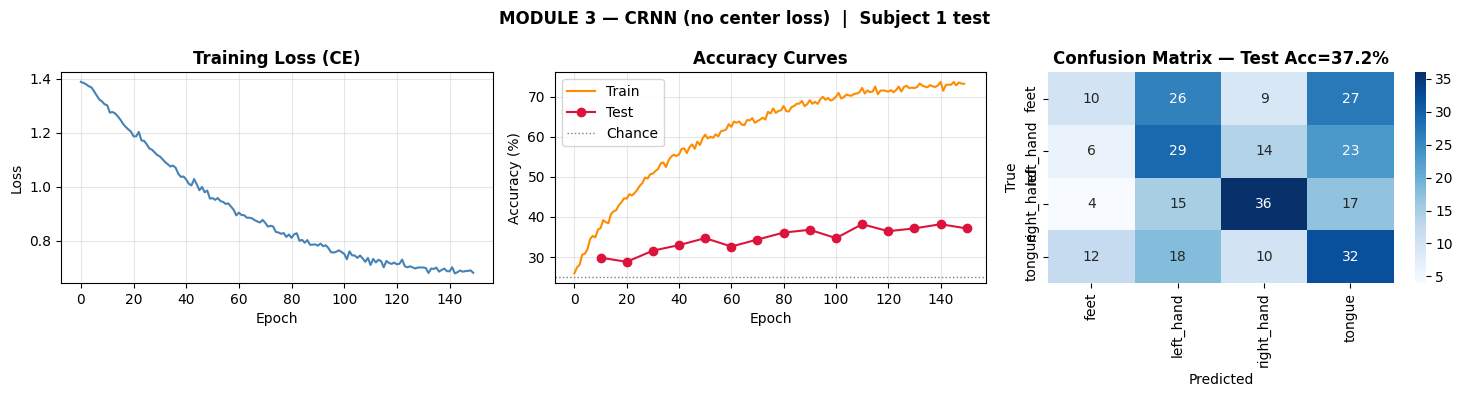

In [5]:
te_epochs = [ep for ep, _ in history['test_acc']]
te_accs   = [acc for _, acc in history['test_acc']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['loss'], color='steelblue')
axes[0].set_title('Training Loss (CE)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], color='darkorange', label='Train')
axes[1].plot(te_epochs, te_accs, 'o-', color='crimson', label='Test')
axes[1].axhline(25, color='gray', ls=':', lw=1, label='Chance')
axes[1].set_title('Accuracy Curves', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_te, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[2].set_title(f'Confusion Matrix — Test Acc={final_acc:.1f}%', fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.suptitle(f'MODULE 3 — CRNN (no center loss)  |  Subject {TEST_SUBJ} test',
             fontweight='bold')
plt.tight_layout()
plt.savefig('m3_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 3.5 Pass/Fail Check

In [6]:
max_train_acc = max(history['train_acc'])
print(f'Max training accuracy : {max_train_acc:.1f}%')
print(f'Final test accuracy   : {final_acc:.1f}%')
print(f'Chance baseline       : 25%')
print(f'Paper CRNN-DF target  : ~65% (subj 1)')

assert max_train_acc > 60, (
    f'FAIL: training acc {max_train_acc:.1f}% — model is not learning.\n'
    f'Check MPS/CUDA, data shapes, and that you re-ran all cells from top.')
assert final_acc > 35, (
    f'FAIL: test acc {final_acc:.1f}% — still near chance. '
    f'CRNN backbone not generalising. Do NOT proceed to Module 4.')

print(f'\n✅  MODULE 3 PASS — CRNN backbone working')
print(f'    Training acc {max_train_acc:.1f}% > 60%  |  '
      f'Test acc {final_acc:.1f}% > 35%')
print('\nSave model weights so Module 4 can load them.')

torch.save(model.state_dict(), 'crnn_baseline_subj1.pt')
print('Saved crnn_baseline_subj1.pt')

Max training accuracy : 73.7%
Final test accuracy   : 37.2%
Chance baseline       : 25%
Paper CRNN-DF target  : ~65% (subj 1)

✅  MODULE 3 PASS — CRNN backbone working
    Training acc 73.7% > 60%  |  Test acc 37.2% > 35%

Save model weights so Module 4 can load them.
Saved crnn_baseline_subj1.pt
